In [9]:
import SUITPy.flatmap as flatmap
import nibabel as nib
import os
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib as mpl


In [10]:
buckner_img = nib.load('atl-Buckner7_space-SUIT_dseg.nii')


In [11]:
buckner_flat = flatmap.vol_to_surf(
    [buckner_img],
    stats='mode',
    space='SUIT',
    ignore_zeros=True
)

/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: divide by zero encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: overflow encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: invalid value encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]


In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [13]:
buckner_cmap = ListedColormap([
    '#771286',  # Visual
    '#4682b4',  # Somatomotor
    '#00760e',  # Dorsal Attention
    '#c43afa',  # Ventral Attention
    '#dcf8a4',  # Limbic
    '#e69422',  # Frontoparietal
    '#cc3e4e'   # Default
])

cscale = [0.5, 7.5]



In [14]:
buckner_flat_clean = buckner_flat.copy()
buckner_flat_clean[np.isnan(buckner_flat_clean)] = 0



In [15]:
np.unique(buckner_flat_clean)

array([0., 1., 2., 3., 4., 5., 6., 7.])

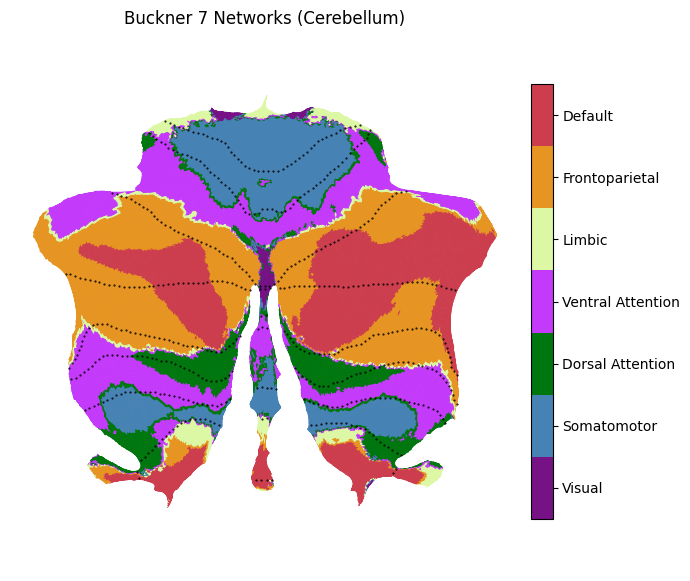

In [16]:
fig = flatmap.plot(
    data=buckner_flat_clean,
    render='matplotlib',
    cmap=buckner_cmap,
    colorbar=False,
    bordersize=1,
    cscale=cscale   # IMPORTANT for discrete labels
)

fig.set_title('Buckner 7 Networks (Cerebellum)')


labels = [
    'Visual',
    'Somatomotor',
    'Dorsal Attention',
    'Ventral Attention',
    'Limbic',
    'Frontoparietal',
    'Default'
]

norm = mpl.colors.Normalize(vmin=0.5, vmax=7.5)

sm = mpl.cm.ScalarMappable(cmap=buckner_cmap, norm=norm)
sm.set_array([])

cbar = fig.figure.colorbar(
    sm,
    ax=fig.figure.axes,
    fraction=0.04,
    pad=0.02
)

cbar.set_ticks(np.arange(1, 8))
cbar.set_ticklabels(labels)

plt.show()


In [17]:
def plot_buckner_on_suit(buckner_img, cmap, labels, title='', output_file=None):
    buckner_flat = flatmap.vol_to_surf(
        [buckner_img],
        stats='mode',
        space='SUIT',
        ignore_zeros=True
    )

    fig = flatmap.plot(
        data=buckner_flat,
        render='matplotlib',
        cmap=cmap,
        colorbar=False,
        bordersize=1,
        cscale=[1, len(labels)+1]
    )

    fig.set_title(title)

    norm = mpl.colors.Normalize(vmin=0.5, vmax=len(labels)+0.5)

    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.figure.colorbar(
        sm,
        ax=fig.figure.axes,
        fraction=0.04,
        pad=0.02
    )

    cbar.set_ticks(np.arange(1, len(labels)+1))
    cbar.set_ticklabels(labels)

    

    return fig


In [18]:
buckner_img = nib.load('atl-Buckner17_space-SUIT_dseg.nii')

In [19]:
# colormap for 17 networks
buckner_cmap = ListedColormap([
    '#1f77b4',  # Visual A
    '#aec7e8',  # Visual B
    '#ff7f0e',  # Somatomotor A
    '#ffbb78',  # Somatomotor B
    '#2ca02c',  # Dorsal Attention A
    '#98df8a',  # Dorsal Attention B
    '#d62728',  # Ventral Attention A
    '#ff9896',  # Ventral Attention B
    '#9467bd',  # Limbic A
    '#c5b0d5',  # Limbic B
    '#8c564b',  # Frontoparietal A
    '#c49c94',  # Frontoparietal B
    '#e377c2',  # Frontoparietal C
    '#f7b6d2',  # Default A
    '#7f7f7f',  # Default B
    '#c7c7c7',  # Default C
    '#bcbd22'   # Default D
])      

labels = [
    'Visual A',
    'Visual B',
    'Somatomotor A',
    'Somatomotor B',
    'Dorsal Attention A',
    'Dorsal Attention B',   
    'Ventral Attention A',
    'Ventral Attention B',
    'Limbic A',
    'Limbic B',
    'Frontoparietal A',
    'Frontoparietal B',
    'Frontoparietal C',
    'Default A',
    'Default B',
    'Default C',
    'Default D'
    ]

/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: divide by zero encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: overflow encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: invalid value encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]


<Axes: title={'center': 'Buckner 17 Networks (Cerebellum)'}>

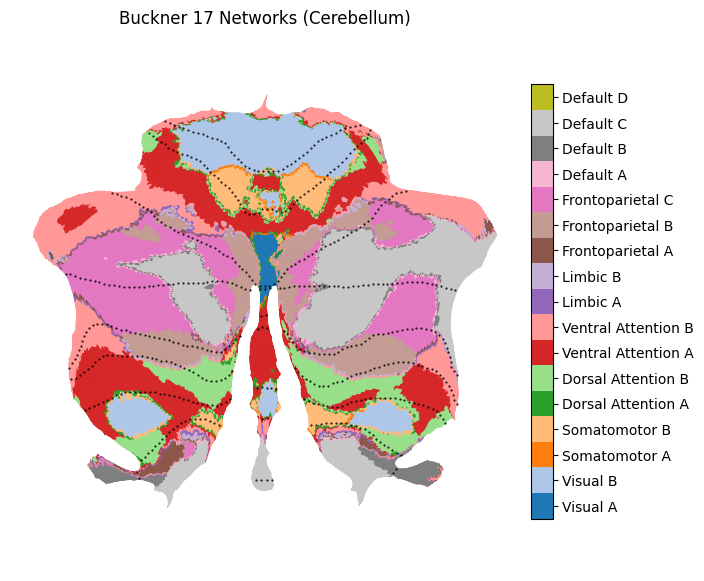

In [20]:
plot_buckner_on_suit(buckner_img, buckner_cmap, labels, title='Buckner 17 Networks (Cerebellum)')

In [21]:
buckner_to_domain = {
    1: 1,  # Visual A → Primary visual
    2: 1,  # Visual B → Primary visual

    3: 3,  # Somatomotor A → Somatomotor
    4: 3,  # Somatomotor B → Somatomotor

    5: 5,  # Dorsal Attention A → Exec/Attention
    6: 5,  # Dorsal Attention B → Exec/Attention

    7: 5,  # Ventral Attention A → Exec/Attention
    8: 4,  # Ventral Attention B → Language

    9: 6,  # Limbic A → Affect
    10: 6, # Limbic B → Affect

    11: 5, # FP A → Exec/Attention
    12: 4, # FP B → Language
    13: 5, # FP C → Exec/Attention

    14: 4, # DMN A → Language (optional)
    15: 4, # DMN B → Language
    16: 6, # DMN C → Affect
    17: 6  # DMN D → Affect
}


In [22]:
import numpy as np
import nibabel as nib

data = buckner_img.get_fdata()
new_data = np.zeros_like(data)

for k, v in buckner_to_domain.items():
    new_data[data == k] = v

domain_img = nib.Nifti1Image(new_data, buckner_img.affine)


/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: divide by zero encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: overflow encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: invalid value encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: divide by zero encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: overflow encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: invalid value encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]


<Axes: title={'center': 'Buckner Domains (Cerebellum)'}>

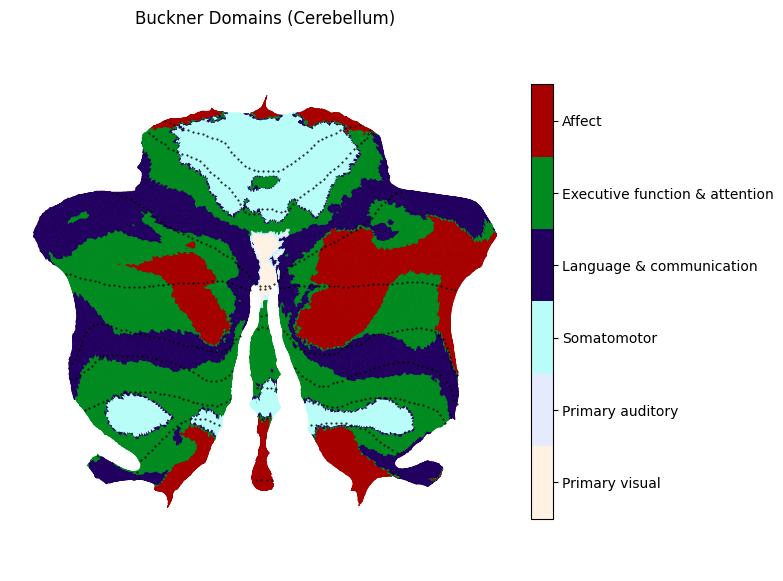

In [23]:
domain_flat = flatmap.vol_to_surf(
    [domain_img],
    stats='mode',
    space='SUIT',
    ignore_zeros=True
)

domain_names = [
    'Primary visual',
    'Primary auditory',
    'Somatomotor',
    'Language & communication',
    'Executive function & attention',
    'Affect'
]

domain_cmap = ListedColormap([
    '#fff2e5',  # Primary visual
    '#e5eaff',  # Primary auditory
    '#b9fdf9',  # Somatomotor
    '#220060',  # Language & communication
    '#008a1f',  # Executive & attention
    '#a60000'   # Affect
])
plot_buckner_on_suit(domain_img, domain_cmap, domain_names, title='Buckner Domains (Cerebellum)')

In [24]:
# label the anatomical lobules on the flatmap
lobules_img = nib.load('atl-Anatom_space-SUIT_dseg.nii')

In [25]:
anatom_tsv = 'atl-Anatom.tsv'
import pandas as pd
anatom_df = pd.read_csv(anatom_tsv, sep='\t')
anatom_labels = anatom_df['name']

In [26]:
def plot_categorical_on_suit(atlas_img, labels_df, title='', output_file=None):
    """
    Plot a categorical atlas (lobules, Buckner, etc.) on SUIT flatmap with correct colors and labels.
    
    atlas_img: Nifti1Image with integer labels
    labels_df: DataFrame with columns ['index', 'name', 'color']
    """
    import numpy as np
    import matplotlib as mpl
    from matplotlib.colors import ListedColormap

    # project to surface
    atlas_flat = flatmap.vol_to_surf(
        [atlas_img],
        stats='mode',
        space='SUIT',
        ignore_zeros=True
    )

    # clean NaNs
    atlas_flat[np.isnan(atlas_flat)] = 0

        # compute safe max label
    max_label = max(int(np.nanmax(atlas_flat)), int(labels_df['index'].max()))

    # initialize colors
    colors = ['#000000'] * (max_label + 1)

    # assign colors from TSV
    for idx, row in labels_df.iterrows():
        colors[row['index']] = row['color']

    # create colormap, skip background
    cmap = ListedColormap(colors[1:-6])

    # plot flatmap
    fig = flatmap.plot(
        data=atlas_flat,
        render='matplotlib',
        cmap=cmap,
        colorbar=False,
        bordersize=1,
        cscale=[0.5, max_label+0.5-6]
    )

    fig.set_title(title)

    # manual colorbar
    norm = mpl.colors.Normalize(vmin=0.5, vmax=max_label+0.5-6)
    sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.figure.colorbar(sm, ax=fig.figure.axes, fraction=0.04, pad=0.02)

    cbar.set_ticks(labels_df['index'][:-6])
    cbar.set_ticklabels(labels_df['name'][:-6])

    if output_file is not None:
        fig.figure.savefig(output_file, dpi=300)
        plt.close(fig.figure)

    return fig


/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: divide by zero encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: overflow encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: invalid value encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]


<Axes: title={'center': 'Cerebellar Lobules'}>

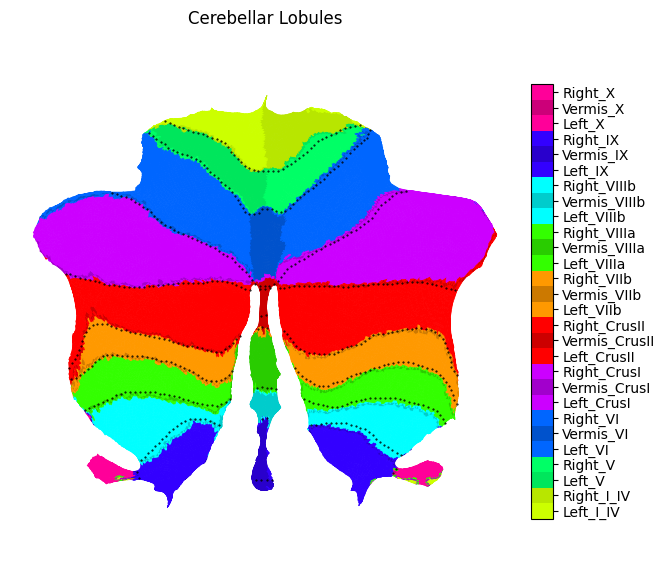

In [27]:
plot_categorical_on_suit(lobules_img, anatom_df, title='Cerebellar Lobules')

In [31]:
anatom_df_duplicate = anatom_df.copy()

In [32]:
anatom_df

,index,name,color
0,1,Left_I_IV,#ccff00
1,2,Right_I_IV,#b8e600
2,3,Left_V,#00e65c
3,4,Right_V,#00ff66
4,5,Left_VI,#0066ff
5,6,Vermis_VI,#0052cc
6,7,Right_VI,#0066ff
7,8,Left_CrusI,#cc00ff
8,9,Vermis_CrusI,#a200cc
9,10,Right_CrusI,#cc00ff


In [60]:
# cluster1 = [
#     'Left_Dentate',
#     'Vermis_IX',
#     'Vermis_VIIIb',
#     'Vermis_X',
#     'Right_X',
#     'Left_X',
#     'Right_IX',
#     'Left_VIIIb',
#     'Left_IX',
#     "Right_Interposed",
#     "Left_Interposed",
#     "Right_Dentate",
#     "Right_V"
# ]

# cluster2 = [
#     'Right_VIIIb',
#     'Left_VIIIa',
#     'Left_VIIb',
#     'Left_CrusII',
#     'Right_VIIIa',
#     'Right_VIIb',
#     'Right_CrusII',
#     'Vermis_CrusII'
# ]

# cluster3 = [
#     'left_global',
#     'Right_CrusI',
#     'right_global',
#     'Vermis_CrusI',
#     'Vermis_VI',
#     'Right_VI',
#     'Left_VI',
#     'Left_CrusI',
#     "Vermis_VIIIa",
#     "Vermis_VIIb",
#     "Left_V",
#     "Right_I_IV",
#     "Left_I_IV"
# ]

#. MSC04
# cluster1 = [
#     'Left_VIIIb', 'Left_VIIb', 'Left_VIIIa', 'Right_X', 'Right_IX', 'Left_IX', 'Left_Dentate', 'Left_X', 'Right_VIIIb', 'Right_VIIb', 'Right_VIIIa', 'Vermis_VIIIb', 'Vermis_VIIIa', 'Vermis_VIIb', 'Vermis_X', 'Vermis_IX', 'Left_CrusII', 'Left_CrusI'
# ]

# cluster2 = [
#     'Right_CrusII', 'Right_CrusI', 'Vermis_CrusII', 'Vermis_CrusI'
# ]

# cluster3 = ['Vermis_VI', 'Left_VI', 'Right_VI', 'Right_V', 'Left_V',  'Right_I_IV', 'Left_I_IV']

# cluster4 = ['Left_Interposed', 'Right_Interposed', 'Right_Dentate']

# for MSC07

# cluster2 = [
#     'Left_VIIIb', 'Left_VIIb', 'Left_VIIIa', 'Right_X',  'Right_VIIIb', 'Right_VIIb', 'Right_VIIIa', 'Right_CrusII', 'Left_CrusII'
# ]

# cluster1 = [
#     'Vermis_IX', 'Vermis_VIIb', 'Vermis_VIIIb', 'Vermis_VIIIa', 'Right_IX', 'Left_IX', 'Vermis_X', 'Left_X', 'Vermis_CrusII', 'Vermis_VI', 'Vermis_CrusI' ]

# cluster3 = ['right_global', 'left_global', 'Left_CrusI', 'Left_VI', 'Right_Dentate', 'Right_VI', 'Right_CrusI', 'Right_I_IV', 'Left_I_IV', 'Right_V', 'Left_V']

# cluster4 = ['Left_Interposed', 'Right_Interposed', 'Left_Dentate']

# cluster4_exist = True

# for MSC01

cluster2 = [
    'Right_VIIIa', 'Left_VIIIa', 'Right_VIIb', 'Left_VIIb', 'Right_CrusII', 'Right_CrusI', 'Left_CrusII', 'Left_CrusI', 'Left_IX', 'Left_VIIIb', 'Right_IX', 'Right_VIIIb'
    ]


cluster1 = [
    'Vermis_IX', 'Vermis_VIIb', 'Vermis_VIIIb', 'Vermis_VIIIa', 'Right_Interposed', 'Left_Interposed', 'Left_Dentate', 'Left_X',  'Vermis_VI' ]

cluster3 = ['Left_VI', 'Right_Dentate', 'Right_VI',  'Right_I_IV', 'Left_I_IV', 'Right_V', 'Left_V', 'Right_X']

cluster4 = ['right_global', 'left_global', 'Vermis_CrusI', 'Vermis_CrusII']


cluster4_exist = True

In [57]:
cluster_colors = [
    "#e61919",  # cluster 1
    "#09820B",  # cluster 2
    "#D37A1C",   # cluster 3
    "#009988",          # teal — interposed + dentate
]

In [61]:
for row in anatom_df_duplicate.itertuples():
    if row.name in cluster1:
        anatom_df_duplicate.at[row.Index, 'color'] = cluster_colors[0]
    elif row.name in cluster2:
        anatom_df_duplicate.at[row.Index, 'color'] = cluster_colors[1]
    elif row.name in cluster3:
        anatom_df_duplicate.at[row.Index, 'color'] = cluster_colors[2]
    elif cluster4_exist and row.name in cluster4:
        anatom_df_duplicate.at[row.Index, 'color'] = cluster_colors[3]

In [40]:
anatom_df_duplicate

,index,name,color
0,1,Left_I_IV,#D37A1C
1,2,Right_I_IV,#D37A1C
2,3,Left_V,#D37A1C
3,4,Right_V,#e61919
4,5,Left_VI,#D37A1C
5,6,Vermis_VI,#D37A1C
6,7,Right_VI,#D37A1C
7,8,Left_CrusI,#D37A1C
8,9,Vermis_CrusI,#D37A1C
9,10,Right_CrusI,#D37A1C


/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: divide by zero encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: overflow encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]
/Users/ajjain/.local/lib/python3.10/site-packages/nitools/volume.py:47: RuntimeWarning: invalid value encountered in matmul
  y = M[0:3,0:3] @ x + M[0:3,3:]


<Axes: title={'center': 'Cerebellar Lobules by Cluster'}>

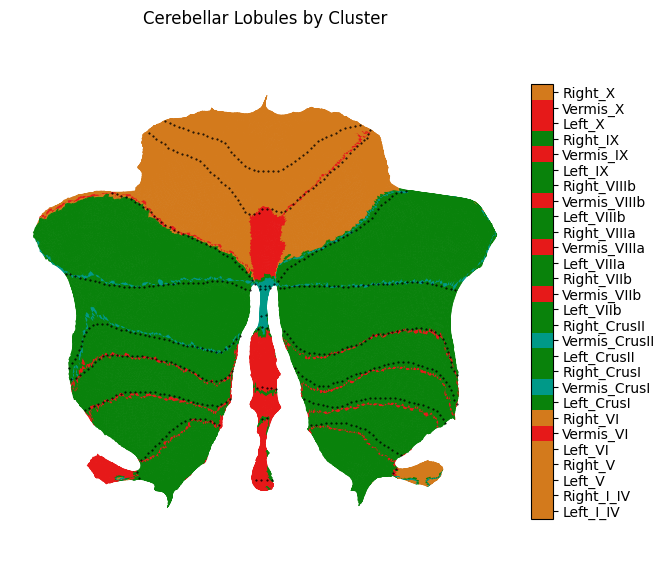

In [62]:
plot_categorical_on_suit(lobules_img, anatom_df_duplicate, title='Cerebellar Lobules by Cluster')